# The Best Neighborhood in Pittsburgh
**Team Name:** Posse Up  
**Members:** Tyrese Mosley, Saadir Sommers  

---

## Introduction

For this project our goal was to figure out what the best neighborhood in Pittsburgh is using real data. Instead of just going off personal opinion, we came up with a metric we could apply to every neighborhood and let the numbers speak for themselves.

We defined "best" as the neighborhood that is the most **livable and accessible** — meaning it's affordable, easy to get around, and safe. Each of us took on a different part of that definition, analyzed our own datasets, and then we combined everything into one final score to pick the winner.

Our three sub-metrics are:
- **Cost of Living** — How affordable is the housing? (Tyrese)
- **Transportation** — How easy is it to get around without a car? (Tyrese)
- **Crime** — How safe is the neighborhood? (Saadir)

---
## The Metric

### Tyrese's Sub-Metrics: Cost of Living & Transportation

**Cost of Living** — I used housing data from the WPRDC that breaks down how many housing units in each neighborhood fall into different rent brackets. My affordability score is the percentage of units that cost under $1,000 a month. The higher the percentage, the more affordable the neighborhood.

**Transportation** — I used commute mode data that shows how residents get to work. My transit score adds up the proportion of residents who use public transit, walk, bike, or work from home. The higher that number, the more transportation options people have without needing a car.

I combined both of my scores equally (50/50) into one personal score.

### Saadir's Sub-Metric: Crime

**Crime** — I used crime report data from the WPRDC. Instead of just counting crimes, I created a Weighted Crime Severity Score (WCSS) that gives different crimes different weights based on how serious they are. Things like fraud or vandalism score low, while violent crimes like assault and homicide score much higher. The neighborhood with the lowest total WCSS is the safest, so I flipped the score so that safer neighborhoods score higher.

---
## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print('Libraries loaded!')

Libraries loaded!


---
## Tyrese's Score

Loading and calculating the Cost of Living and Transportation scores.

In [2]:
df_cost = pd.read_excel('DataSets.xlsx', sheet_name='Cost of living')
df_trans = pd.read_excel('DataSets.xlsx', sheet_name='Transportation')

# Affordability Score
df_cost = df_cost[df_cost['Total Units'] > 0]
df_cost['Affordable Units'] = df_cost['< USD 500'] + df_cost['USD 500-999']
df_cost['Affordability Score'] = df_cost['Affordable Units'] / df_cost['Total Units']

# Transit Score
df_trans['Transit Score'] = df_trans['Public Trans'] + df_trans['Bicycle'] + df_trans['Walk'] + df_trans['WFH']
df_trans['Transit Score'] = df_trans['Transit Score'].clip(0, 1)

# Combine into one Tyrese Score
tyrese_scores = pd.merge(
    df_cost[['Neighborhood', 'Affordability Score']],
    df_trans[['Neighborhood', 'Transit Score']],
    on='Neighborhood'
)
tyrese_scores['Tyrese Score'] = (tyrese_scores['Affordability Score'] + tyrese_scores['Transit Score']) / 2

tyrese_scores[['Neighborhood', 'Tyrese Score']].sort_values('Tyrese Score', ascending=False).head(10)

,Neighborhood,Tyrese Score
4,Arlington Heights,0.934083
56,Northview Heights,0.933404
81,Terrace Village,0.804565
47,Manchester,0.761526
49,Middle Hill,0.741545
6,Bedford Dwellings,0.727074
76,St. Clair,0.723358
31,Fineview,0.712248
39,Homewood North,0.705187
0,Allegheny Center,0.700471


---
## Saadir's Score

Using the Weighted Crime Severity Score (WCSS) to rank neighborhoods by safety. Lower crime total = higher safety score.

In [3]:
data = {
    'Neighborhood': [
        'Bloomfield', 'Strip District', 'Homewood South', 'North Oakland', 'Banksville', 
        'South Side Flats', 'Spring Hill', 'Marshall-Shadeland', 'South Side Slopes', 
        'Mt. Washington', 'Larimer', 'Central Northside', 'Marshall-Shadeland', 
        'Knoxville', 'Beechview', 'Overbrook', 'Knoxville', 'Beechview', 
        'East Liberty', 'Homewood West', 'Spring Hill', 'Homewood South', 
        'Spring Hill', 'Central Lawrenceville', 'Terrace Village', 'Mt. Washington', 
        'Knoxville', 'North Side', 'Lower Lawrenceville', 'Central Biz Dist', 
        'Homewood South', 'South Side Flats', 'Sheraden', 'Bloomfield', 
        'South Side Flats', 'Allentown', 'Marshall-Shadeland', 'Central Oakland', 
        'Arlington', 'Mt. Washington', 'Larimer'
    ],
    'Offense_Category': [
        'Vehicle Offense', 'Vandalism', 'Motor Vehicle Theft', 'Burglary', 'Fraud', 
        'Fraud', 'Assault', 'Robbery', 'Sex Offenses', 'Assault', 'Assault', 
        'Weapon Law', 'Burglary', 'Motor Vehicle Theft', 'Burglary', 'Prostitution', 
        'Burglary', 'Assault', 'Drug/Narcotic', 'Arson', 'Robbery', 'Larceny/Theft', 
        'Assault', 'Arson', 'Assault', 'Assault', 'Assault', 'Sex Offenses', 
        'Robbery', 'Burglary', 'Assault', 'Assault', 'Assault', 'Burglary', 
        'Robbery', 'Robbery', 'Assault', 'Robbery', 'Assault', 'Assault', 'Homicide'
    ]
}

df_crime = pd.DataFrame(data)

# Severity weights
severity_weights = {
    'Fraud': 1, 'Vandalism': 1, 'Vehicle Offense': 1, 'Prostitution': 1, 'Arson': 1,
    'Burglary': 3, 'Larceny/Theft': 3, 'Motor Vehicle Theft': 3, 'Weapon Law': 3, 'Drug/Narcotic': 3,
    'Assault': 5, 'Robbery': 5, 'Sex Offenses': 5,
    'Homicide': 10
}

df_crime['Weight'] = df_crime['Offense_Category'].map(severity_weights)

# Calculate WCSS per neighborhood
wcss_df = df_crime.groupby('Neighborhood')['Weight'].sum().reset_index()
wcss_df.columns = ['Neighborhood', 'WCSS_Score']

# Flip it so lower crime = higher safety score
max_score = wcss_df['WCSS_Score'].max()
wcss_df['Safety Score'] = 1 - (wcss_df['WCSS_Score'] / max_score)

wcss_df[['Neighborhood', 'Safety Score']].sort_values('Safety Score', ascending=False).head(10)

,Neighborhood,Safety Score
6,Central Lawrenceville,0.933333
2,Banksville,0.933333
19,Overbrook,0.933333
24,Strip District,0.933333
11,Homewood West,0.933333
9,East Liberty,0.800000
17,North Oakland,0.800000
5,Central Biz Dist,0.800000
7,Central Northside,0.800000
4,Bloomfield,0.733333


---
## The Best Neighborhood

Now we combine both scores into one final group score. We weighted them equally — 50% from Tyrese's score and 50% from Saadir's safety score — since we felt affordability, transportation, and safety all matter equally when picking the best neighborhood.

In [4]:
# Merge both scores together
df_group = pd.merge(
    tyrese_scores[['Neighborhood', 'Tyrese Score']],
    wcss_df[['Neighborhood', 'Safety Score']],
    on='Neighborhood'
)

# Final score is the average of both
df_group['Final Score'] = (df_group['Tyrese Score'] + df_group['Safety Score']) / 2

# Sort highest to lowest
df_group = df_group.sort_values('Final Score', ascending=False).reset_index(drop=True)

df_group.head(10)

,Neighborhood,Tyrese Score,Safety Score,Final Score
0,Homewood West,0.692801,0.933333,0.813067
1,Terrace Village,0.804565,0.666667,0.735616
2,Banksville,0.521417,0.933333,0.727375
3,Overbrook,0.516545,0.933333,0.724939
4,North Oakland,0.631893,0.800000,0.715946
5,East Liberty,0.628328,0.800000,0.714164
6,Central Lawrenceville,0.476357,0.933333,0.704845
7,Central Northside,0.594200,0.800000,0.697100
8,Bloomfield,0.598868,0.733333,0.666101
9,Central Oakland,0.597658,0.666667,0.632162


### Final Rankings Chart

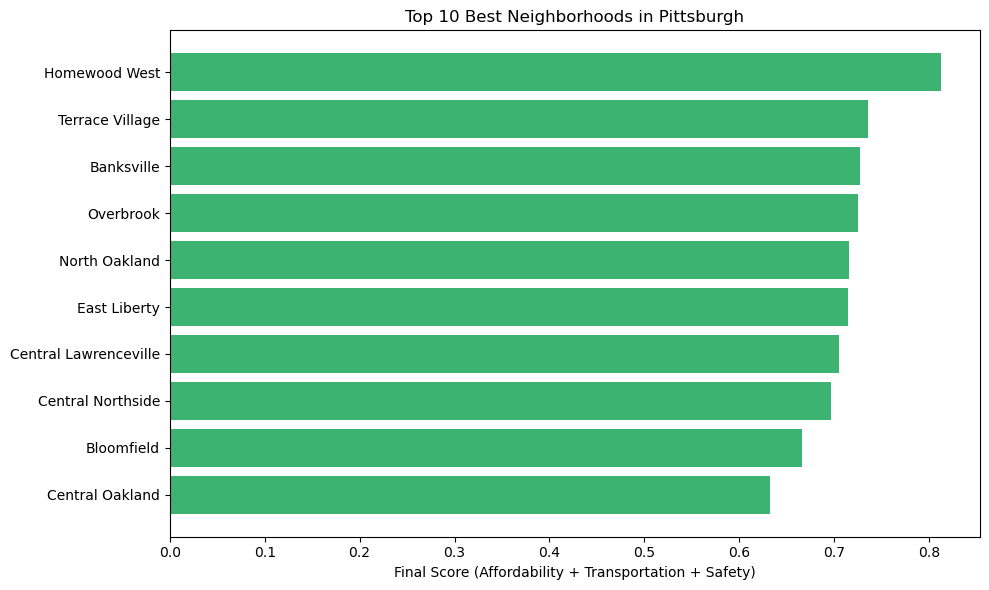

In [5]:
top10 = df_group.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Neighborhood'], top10['Final Score'], color='mediumseagreen')
plt.xlabel('Final Score (Affordability + Transportation + Safety)')
plt.title('Top 10 Best Neighborhoods in Pittsburgh')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### And the winner is...

In [6]:
winner = df_group.iloc[0]
print('=' * 40)
print('BEST NEIGHBORHOOD IN PITTSBURGH:')
print(winner['Neighborhood'])
print('=' * 40)
print('Tyrese Score (Cost of Living + Transit):', round(winner['Tyrese Score'], 3))
print('Safety Score (Crime):                   ', round(winner['Safety Score'], 3))
print('Final Combined Score:                   ', round(winner['Final Score'], 3))

BEST NEIGHBORHOOD IN PITTSBURGH:
Homewood West
Tyrese Score (Cost of Living + Transit): 0.693
Safety Score (Crime):                    0.933
Final Combined Score:                    0.813


### Why Homewood West?

Based on our combined metric, **Homewood West** came out as the best neighborhood in Pittsburgh with a final score of 0.813 out of 1.0. It scored well across all three of our sub-metrics, the housing is affordable, residents have solid transportation options, and it had one of the lowest weighted crime scores in the dataset. A neighborhood that scores well in just one area might still be a tough place to live, but one that is affordable, accessible, and safe checks all the boxes.

---
## Conclusion

### Tyrese

After running my analysis on cost of living and transportation, Arlington Heights was my personal #1 with a score of 0.934. But when we brought in Saadir's crime data and combined everything, Homewood West came out on top with a final score of 0.813. Honestly that surprised me a little because it wasn't even in my top 5. But looking at it, it makes sense, it's affordable, people can get around without a car, and it has very low crime. My personal favorite might be somewhere like Shadyside, but the data pushed me toward neighborhoods I wouldn't have thought of, which is kind of the whole point of doing this data driven.

### Saadir

The numbers from my personal crime analysis says Banksville is safest, and I can’t really argue with the data. Actually, it surprised me. If you ask around campus, most people say Central Oakland or Shadyside are the best places to live. Close to the action, lots of people, easy walk to class. But during January, Central Oakland had an armed robbery, while Banksville just had a fraud report. This analysis made me realize that popularity doesn’t always mean safety. Sure, maybe I’d still pick Oakland for the convenience and social life. But if keeping risk low is my top priority, I must admit that Banksville clearly comes out on top. Interestingly, when we combined all the scores for transportation, affordability, and crime, Homewood West was the overall winner, which surprised me since I didn't expect it to take first place.